# Lung Segmentation

In [1]:
import torch

print('PyTorch version:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
print('Device:', 'cuda' if torch.cuda.is_available() else 'cpu')

PyTorch version: 2.10.0+cu126
CUDA available: True
Device: cuda


### Preprocess JSRT + SHCXR Dataset

In [2]:
from preprocess import preprocess_all
preprocess_all()

Preprocessing dataset : JSRT
Total raw images found : 247
Total raw masks found : 247
Matched image-mask pairs : 247
Images without masks ignored: 0
Masks without images ignored: 0
Saved preprocessed image to data\jsrt\images
Saved preprocessed mask to data\jsrt\masks
JSRT preprocessing complete
Preprocessing dataset : SHCXR
Total raw images found : 662
Total raw masks found : 566
Matched image-mask pairs : 566
Images without masks ignored: 96
Masks without images ignored: 0
Saved preprocessed image to data\shcxr\images
Saved preprocessed mask to data\shcxr\masks
SHCXR preprocessing complete


### Training

#### UNet on SHCXR

In [3]:
!python train.py --model unet --dataset shcxr --image_dir data/shcxr/images --mask_dir data/shcxr/masks --epochs 25 --batch_size 8 --lr 0.0001

Using device: cuda
Training unet on shcxr
Saved split indices to split_unet_shcxr.json
Epoch [1/25] - Loss: 0.6502 - Val Dice: 0.9474 - Val IoU: 0.9011
Epoch [2/25] - Loss: 0.4486 - Val Dice: 0.9561 - Val IoU: 0.9172
Epoch [3/25] - Loss: 0.3995 - Val Dice: 0.9575 - Val IoU: 0.9196
Epoch [4/25] - Loss: 0.3628 - Val Dice: 0.9562 - Val IoU: 0.9172
Epoch [5/25] - Loss: 0.3304 - Val Dice: 0.9571 - Val IoU: 0.9191
Epoch [6/25] - Loss: 0.3078 - Val Dice: 0.9596 - Val IoU: 0.9236
Epoch [7/25] - Loss: 0.2826 - Val Dice: 0.9596 - Val IoU: 0.9236
Epoch [8/25] - Loss: 0.2621 - Val Dice: 0.9591 - Val IoU: 0.9227
Epoch [9/25] - Loss: 0.2412 - Val Dice: 0.9595 - Val IoU: 0.9233
Epoch [10/25] - Loss: 0.2263 - Val Dice: 0.9599 - Val IoU: 0.9242
Epoch [11/25] - Loss: 0.2154 - Val Dice: 0.9579 - Val IoU: 0.9204
Epoch [12/25] - Loss: 0.2093 - Val Dice: 0.9583 - Val IoU: 0.9212
Epoch [13/25] - Loss: 0.1950 - Val Dice: 0.9608 - Val IoU: 0.9258
Epoch [14/25] - Loss: 0.1888 - Val Dice: 0.9588 - Val IoU: 0.922

d:\0. Omisha\UoU\Sem 4\DLI\Lung-Segmentation\train.py:96: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
d:\0. Omisha\UoU\Sem 4\DLI\Lung-Segmentation\train.py:113: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


#### UNet on JSRT

In [4]:
!python train.py --model unet --dataset jsrt --image_dir data/jsrt/images --mask_dir data/jsrt/masks --epochs 25 --batch_size 8 --lr 0.0001

Using device: cuda
Training unet on jsrt
Saved split indices to split_unet_jsrt.json
Epoch [1/25] - Loss: 0.7529 - Val Dice: 0.8104 - Val IoU: 0.6869
Epoch [2/25] - Loss: 0.4269 - Val Dice: 0.9509 - Val IoU: 0.9069
Epoch [3/25] - Loss: 0.3709 - Val Dice: 0.9633 - Val IoU: 0.9295
Epoch [4/25] - Loss: 0.3404 - Val Dice: 0.9705 - Val IoU: 0.9429
Epoch [5/25] - Loss: 0.3140 - Val Dice: 0.9707 - Val IoU: 0.9433
Epoch [6/25] - Loss: 0.2975 - Val Dice: 0.9732 - Val IoU: 0.9480
Epoch [7/25] - Loss: 0.2781 - Val Dice: 0.9750 - Val IoU: 0.9514
Epoch [8/25] - Loss: 0.2622 - Val Dice: 0.9752 - Val IoU: 0.9519
Epoch [9/25] - Loss: 0.2532 - Val Dice: 0.9749 - Val IoU: 0.9513
Epoch [10/25] - Loss: 0.2387 - Val Dice: 0.9745 - Val IoU: 0.9504
Epoch [11/25] - Loss: 0.2261 - Val Dice: 0.9776 - Val IoU: 0.9564
Epoch [12/25] - Loss: 0.2145 - Val Dice: 0.9772 - Val IoU: 0.9555
Epoch [13/25] - Loss: 0.2050 - Val Dice: 0.9757 - Val IoU: 0.9527
Epoch [14/25] - Loss: 0.1962 - Val Dice: 0.9747 - Val IoU: 0.9508


d:\0. Omisha\UoU\Sem 4\DLI\Lung-Segmentation\train.py:96: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
d:\0. Omisha\UoU\Sem 4\DLI\Lung-Segmentation\train.py:113: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


#### ResUNet on SHCXR

In [5]:
!python train.py --model resunet --dataset shcxr --image_dir data/shcxr/images --mask_dir data/shcxr/masks --epochs 25 --batch_size 8 --lr 0.0001

Using device: cuda
Training resunet on shcxr
Saved split indices to split_resunet_shcxr.json
Epoch [1/25] - Loss: 0.4587 - Val Dice: 0.9500 - Val IoU: 0.9060
Epoch [2/25] - Loss: 0.2064 - Val Dice: 0.9544 - Val IoU: 0.9138
Epoch [3/25] - Loss: 0.1812 - Val Dice: 0.9498 - Val IoU: 0.9067
Epoch [4/25] - Loss: 0.1652 - Val Dice: 0.9588 - Val IoU: 0.9222
Epoch [5/25] - Loss: 0.1473 - Val Dice: 0.9587 - Val IoU: 0.9219
Epoch [6/25] - Loss: 0.1391 - Val Dice: 0.9587 - Val IoU: 0.9220
Epoch [7/25] - Loss: 0.1310 - Val Dice: 0.9591 - Val IoU: 0.9226
Epoch [8/25] - Loss: 0.1285 - Val Dice: 0.9560 - Val IoU: 0.9172
Epoch [9/25] - Loss: 0.1242 - Val Dice: 0.9595 - Val IoU: 0.9235
Epoch [10/25] - Loss: 0.1193 - Val Dice: 0.9587 - Val IoU: 0.9222
Epoch [11/25] - Loss: 0.1162 - Val Dice: 0.9594 - Val IoU: 0.9232
Epoch [12/25] - Loss: 0.1145 - Val Dice: 0.9602 - Val IoU: 0.9246
Epoch [13/25] - Loss: 0.1139 - Val Dice: 0.9604 - Val IoU: 0.9253
Epoch [14/25] - Loss: 0.1110 - Val Dice: 0.9588 - Val IoU:

d:\0. Omisha\UoU\Sem 4\DLI\Lung-Segmentation\train.py:96: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
d:\0. Omisha\UoU\Sem 4\DLI\Lung-Segmentation\train.py:113: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


#### ResUNet on JSRT

In [6]:
!python train.py --model resunet --dataset jsrt --image_dir data/jsrt/images --mask_dir data/jsrt/masks --epochs 25 --batch_size 8 --lr 0.0001

Using device: cuda
Training resunet on jsrt
Saved split indices to split_resunet_jsrt.json
Epoch [1/25] - Loss: 0.5996 - Val Dice: 0.8908 - Val IoU: 0.8063
Epoch [2/25] - Loss: 0.2260 - Val Dice: 0.9543 - Val IoU: 0.9129
Epoch [3/25] - Loss: 0.1715 - Val Dice: 0.9625 - Val IoU: 0.9284
Epoch [4/25] - Loss: 0.1472 - Val Dice: 0.9714 - Val IoU: 0.9447
Epoch [5/25] - Loss: 0.1316 - Val Dice: 0.9569 - Val IoU: 0.9200
Epoch [6/25] - Loss: 0.1159 - Val Dice: 0.9704 - Val IoU: 0.9428
Epoch [7/25] - Loss: 0.1053 - Val Dice: 0.9758 - Val IoU: 0.9530
Epoch [8/25] - Loss: 0.0972 - Val Dice: 0.9749 - Val IoU: 0.9511
Epoch [9/25] - Loss: 0.0927 - Val Dice: 0.9741 - Val IoU: 0.9497
Epoch [10/25] - Loss: 0.0887 - Val Dice: 0.9770 - Val IoU: 0.9553
Epoch [11/25] - Loss: 0.0832 - Val Dice: 0.9770 - Val IoU: 0.9552
Epoch [12/25] - Loss: 0.0793 - Val Dice: 0.9761 - Val IoU: 0.9535
Epoch [13/25] - Loss: 0.0773 - Val Dice: 0.9775 - Val IoU: 0.9562
Epoch [14/25] - Loss: 0.0725 - Val Dice: 0.9769 - Val IoU: 0

d:\0. Omisha\UoU\Sem 4\DLI\Lung-Segmentation\train.py:96: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
d:\0. Omisha\UoU\Sem 4\DLI\Lung-Segmentation\train.py:113: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


### Evaluation

1. **Within-dataset evaluation**
   - The model is tested on the same dataset it is trained on.

2. **Cross-dataset evaluation**
   - The model is tested on a different dataset from the one it was trained on.

For each model, we perform the following experiments:

- Train on SHCXR → Test on SHCXR (baseline)
- Train on SHCXR → Test on JSRT (cross-dataset)
- Train on JSRT → Test on JSRT (baseline)
- Train on JSRT → Test on SHCXR (cross-dataset)

This results in a total of **8 experiments** across both models.

In [7]:
!python run_eval.py

U-Net: train SHCXR -> test SHCXR
Using val split from split_unet_shcxr.json
Number of samples in split: 113
Model: unet
Checkpoint: best_unet_shcxr.pth
Test images: data/shcxr/images
Average Dice Score: 0.9616
Average IoU Score: 0.9273
U-Net: train SHCXR -> test JSRT
Model: unet
Checkpoint: best_unet_shcxr.pth
Test images: data/jsrt/images
Average Dice Score: 0.9648
Average IoU Score: 0.9325
U-Net: train JSRT -> test JSRT
Using val split from split_unet_jsrt.json
Number of samples in split: 49
Model: unet
Checkpoint: best_unet_jsrt.pth
Test images: data/jsrt/images
Average Dice Score: 0.9787
Average IoU Score: 0.9585
U-Net: train JSRT -> test SHCXR
Model: unet
Checkpoint: best_unet_jsrt.pth
Test images: data/shcxr/images
Average Dice Score: 0.9384
Average IoU Score: 0.8882
ResUNet: train SHCXR -> test SHCXR
Using val split from split_resunet_shcxr.json
Number of samples in split: 113
Model: resunet
Checkpoint: best_resunet_shcxr.pth
Test images: data/shcxr/images
Average Dice Score: 0.

#### Results CSV

In [8]:
import pandas as pd
results = pd.read_csv('evaluation_results.csv')
results

,Model,Trained On,Tested On,Dice Score,IoU Score
0,U-Net,SHCXR,SHCXR,0.9616,0.9273
1,U-Net,SHCXR,JSRT,0.9648,0.9325
2,U-Net,JSRT,JSRT,0.9787,0.9585
3,U-Net,JSRT,SHCXR,0.9384,0.8882
4,ResUNet,SHCXR,SHCXR,0.9611,0.9264
5,ResUNet,SHCXR,JSRT,0.9337,0.8851
6,ResUNet,JSRT,JSRT,0.9793,0.9596
7,ResUNet,JSRT,SHCXR,0.9458,0.9006


#### Evaluation Metrics Visualization
Bar plots to compare Dice and IoU scores across all experiments


,Model,Trained On,Tested On,Dice Score,IoU Score,Setting
0,U-Net,SHCXR,SHCXR,0.9616,0.9273,SHCXR → SHCXR
1,U-Net,SHCXR,JSRT,0.9648,0.9325,SHCXR → JSRT
2,U-Net,JSRT,JSRT,0.9787,0.9585,JSRT → JSRT
3,U-Net,JSRT,SHCXR,0.9384,0.8882,JSRT → SHCXR
4,ResUNet,SHCXR,SHCXR,0.9611,0.9264,SHCXR → SHCXR
5,ResUNet,SHCXR,JSRT,0.9337,0.8851,SHCXR → JSRT
6,ResUNet,JSRT,JSRT,0.9793,0.9596,JSRT → JSRT
7,ResUNet,JSRT,SHCXR,0.9458,0.9006,JSRT → SHCXR


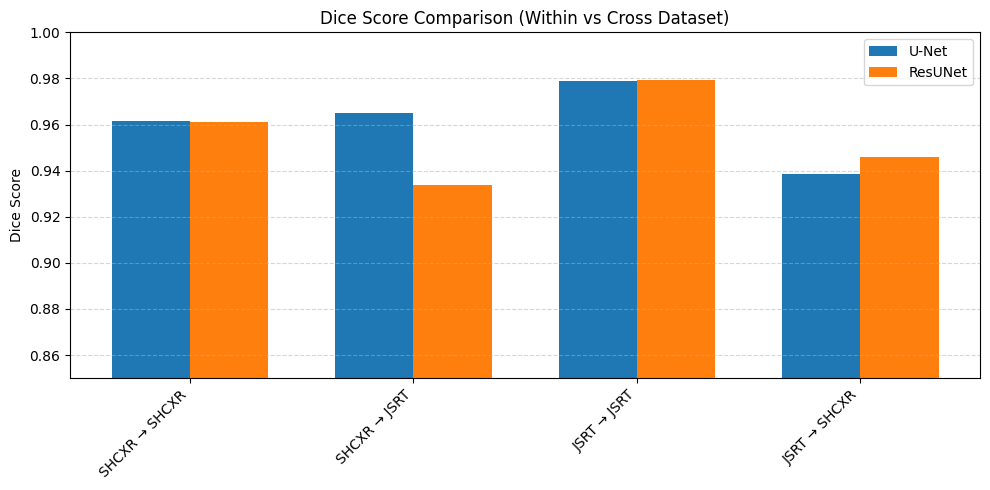

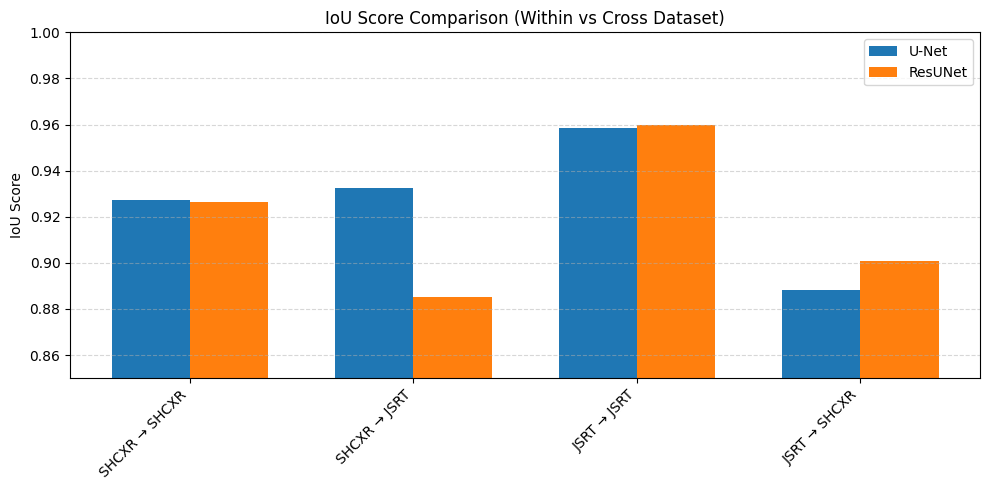

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load results
df = pd.read_csv("evaluation_results.csv")
df["Dice Score"] = df["Dice Score"].astype(float)
df["IoU Score"] = df["IoU Score"].astype(float)

df["Setting"] = df["Trained On"] + " → " + df["Tested On"]

# Display table
display(df)

# Unique values
settings = df["Setting"].unique()
models = df["Model"].unique()

x = np.arange(len(settings))
width = 0.35

# =========================
# Dice Score Plot
# =========================
plt.figure(figsize=(10, 5))

for i, model in enumerate(models):
    subset = df[df["Model"] == model]
    plt.bar(x + i*width, subset["Dice Score"], width, label=model)

plt.xticks(x + width/2, settings, rotation=45, ha="right")
plt.ylabel("Dice Score")
plt.title("Dice Score Comparison (Within vs Cross Dataset)")
plt.ylim(0.85, 1.0)  # zoom for visibility
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


# =========================
# IoU Score Plot
# =========================
plt.figure(figsize=(10, 5))

for i, model in enumerate(models):
    subset = df[df["Model"] == model]
    plt.bar(x + i*width, subset["IoU Score"], width, label=model)

plt.xticks(x + width/2, settings, rotation=45, ha="right")
plt.ylabel("IoU Score")
plt.title("IoU Score Comparison (Within vs Cross Dataset)")
plt.ylim(0.85, 1.0)
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

#### Training Curves


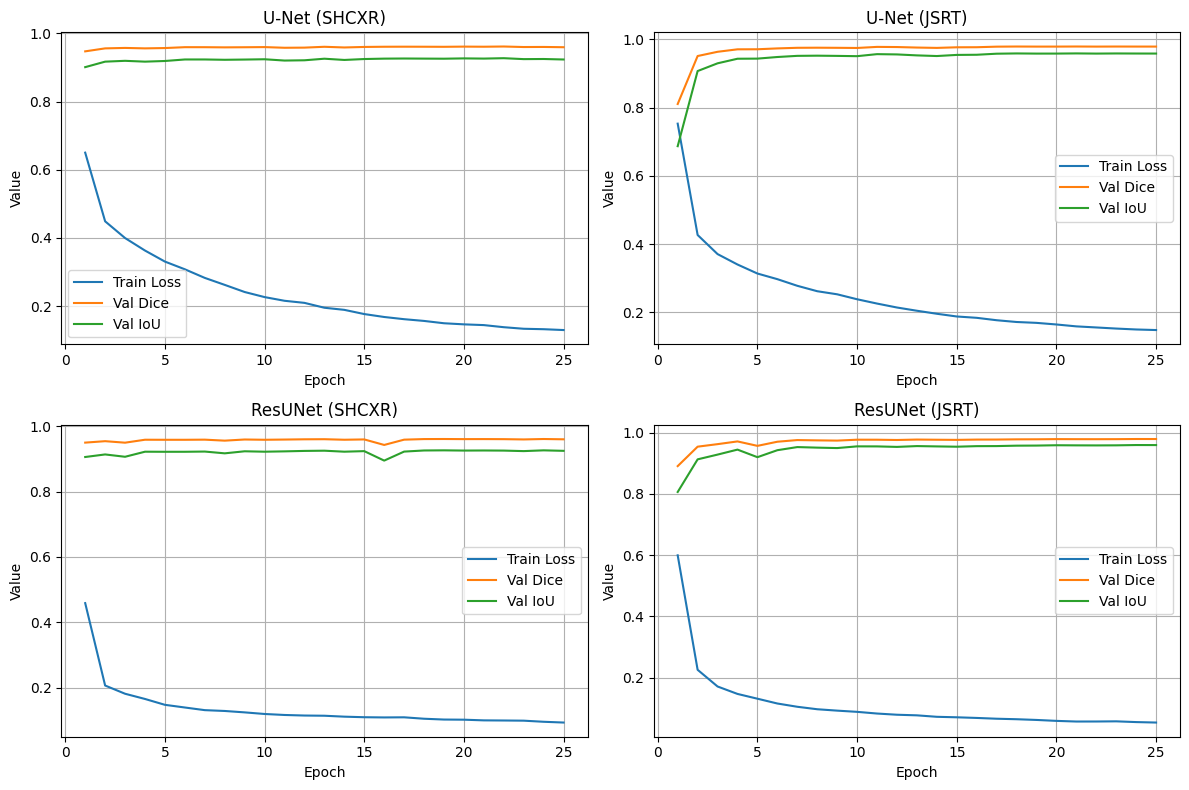

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

files = [
    ("history_unet_shcxr.csv", "U-Net (SHCXR)"),
    ("history_unet_jsrt.csv", "U-Net (JSRT)"),
    ("history_resunet_shcxr.csv", "ResUNet (SHCXR)"),
    ("history_resunet_jsrt.csv", "ResUNet (JSRT)"),
]

plt.figure(figsize=(12, 8))

for i, (file, title) in enumerate(files):
    hist = pd.read_csv(file)

    plt.subplot(2, 2, i + 1)
    plt.plot(hist["epoch"], hist["train_loss"], label="Train Loss")
    plt.plot(hist["epoch"], hist["val_dice"], label="Val Dice")
    plt.plot(hist["epoch"], hist["val_iou"], label="Val IoU")

    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

### Visualizing model predictions on sample images

1. **Input Image** – the original chest X-ray  
2. **Ground Truth Mask** – the manually annotated lung region  
3. **Predicted Mask** – the model’s segmentation output  

UNet trained on SHCXR | Test: SHCXR

In [11]:
!python pred_vis.py --model unet --model_path best_unet_shcxr.pth --image_dir data/shcxr/images --mask_dir data/shcxr/masks --output_dir pred_vis/unet_shcxr_to_shcxr

Saved pred_vis/unet_shcxr_to_shcxr\prediction_001_sample_1.png
Saved pred_vis/unet_shcxr_to_shcxr\prediction_002_sample_2.png
Saved pred_vis/unet_shcxr_to_shcxr\prediction_003_sample_3.png
Saved pred_vis/unet_shcxr_to_shcxr\prediction_004_sample_4.png
Saved pred_vis/unet_shcxr_to_shcxr\prediction_005_sample_5.png


UNet trained on SHCXR | Test: JSRT

In [12]:
!python pred_vis.py --model unet --model_path best_unet_shcxr.pth --image_dir data/jsrt/images --mask_dir data/jsrt/masks --output_dir pred_vis/unet_shcxr_to_jsrt

Saved pred_vis/unet_shcxr_to_jsrt\prediction_001_sample_1.png
Saved pred_vis/unet_shcxr_to_jsrt\prediction_002_sample_2.png
Saved pred_vis/unet_shcxr_to_jsrt\prediction_003_sample_3.png
Saved pred_vis/unet_shcxr_to_jsrt\prediction_004_sample_4.png
Saved pred_vis/unet_shcxr_to_jsrt\prediction_005_sample_5.png


ResUNet trained on JSRT | Test: JSRT

In [13]:
!python pred_vis.py --model resunet --model_path best_resunet_jsrt.pth --image_dir data/jsrt/images --mask_dir data/jsrt/masks --output_dir pred_vis/resunet_jsrt_to_jsrt

Saved pred_vis/resunet_jsrt_to_jsrt\prediction_001_sample_1.png
Saved pred_vis/resunet_jsrt_to_jsrt\prediction_002_sample_2.png
Saved pred_vis/resunet_jsrt_to_jsrt\prediction_003_sample_3.png
Saved pred_vis/resunet_jsrt_to_jsrt\prediction_004_sample_4.png
Saved pred_vis/resunet_jsrt_to_jsrt\prediction_005_sample_5.png


ResUNet trained on JSRT | Test: SHCXR

In [14]:
!python pred_vis.py --model resunet --model_path best_resunet_jsrt.pth --image_dir data/shcxr/images --mask_dir data/shcxr/masks --output_dir pred_vis/resunet_jsrt_to_shcxr

Saved pred_vis/resunet_jsrt_to_shcxr\prediction_001_sample_1.png
Saved pred_vis/resunet_jsrt_to_shcxr\prediction_002_sample_2.png
Saved pred_vis/resunet_jsrt_to_shcxr\prediction_003_sample_3.png
Saved pred_vis/resunet_jsrt_to_shcxr\prediction_004_sample_4.png
Saved pred_vis/resunet_jsrt_to_shcxr\prediction_005_sample_5.png


UNet trained on JSRT | Test: JSRT

In [15]:
!python pred_vis.py --model unet --model_path best_unet_jsrt.pth --image_dir data/jsrt/images --mask_dir data/jsrt/masks --output_dir pred_vis/unet_jsrt_to_jsrt --num_examples 5 --image_size 256

Saved pred_vis/unet_jsrt_to_jsrt\prediction_001_sample_1.png
Saved pred_vis/unet_jsrt_to_jsrt\prediction_002_sample_2.png
Saved pred_vis/unet_jsrt_to_jsrt\prediction_003_sample_3.png
Saved pred_vis/unet_jsrt_to_jsrt\prediction_004_sample_4.png
Saved pred_vis/unet_jsrt_to_jsrt\prediction_005_sample_5.png


UNet trained on JSRT | Test: SHCXR

In [16]:
!python pred_vis.py --model unet --model_path best_unet_jsrt.pth --image_dir data/shcxr/images --mask_dir data/shcxr/masks --output_dir pred_vis/unet_jsrt_to_shcxr --num_examples 5 --image_size 256

Saved pred_vis/unet_jsrt_to_shcxr\prediction_001_sample_1.png
Saved pred_vis/unet_jsrt_to_shcxr\prediction_002_sample_2.png
Saved pred_vis/unet_jsrt_to_shcxr\prediction_003_sample_3.png
Saved pred_vis/unet_jsrt_to_shcxr\prediction_004_sample_4.png
Saved pred_vis/unet_jsrt_to_shcxr\prediction_005_sample_5.png


ResUNet trained on SHCXR | Test: SHCXR

In [17]:
!python pred_vis.py --model resunet --model_path best_resunet_shcxr.pth --image_dir data/shcxr/images --mask_dir data/shcxr/masks --output_dir pred_vis/resunet_shcxr_to_shcxr --num_examples 5 --image_size 256

Saved pred_vis/resunet_shcxr_to_shcxr\prediction_001_sample_1.png
Saved pred_vis/resunet_shcxr_to_shcxr\prediction_002_sample_2.png
Saved pred_vis/resunet_shcxr_to_shcxr\prediction_003_sample_3.png
Saved pred_vis/resunet_shcxr_to_shcxr\prediction_004_sample_4.png
Saved pred_vis/resunet_shcxr_to_shcxr\prediction_005_sample_5.png


ResUNet trained on SHCXR | Test: JSRT

In [18]:
!python pred_vis.py --model resunet --model_path best_resunet_shcxr.pth --image_dir data/jsrt/images --mask_dir data/jsrt/masks --output_dir pred_vis/resunet_shcxr_to_jsrt --num_examples 5 --image_size 256

Saved pred_vis/resunet_shcxr_to_jsrt\prediction_001_sample_1.png
Saved pred_vis/resunet_shcxr_to_jsrt\prediction_002_sample_2.png
Saved pred_vis/resunet_shcxr_to_jsrt\prediction_003_sample_3.png
Saved pred_vis/resunet_shcxr_to_jsrt\prediction_004_sample_4.png
Saved pred_vis/resunet_shcxr_to_jsrt\prediction_005_sample_5.png


#### Display VIsualizations

U-Net (SHCXR --> SHCXR) : Within-dataset


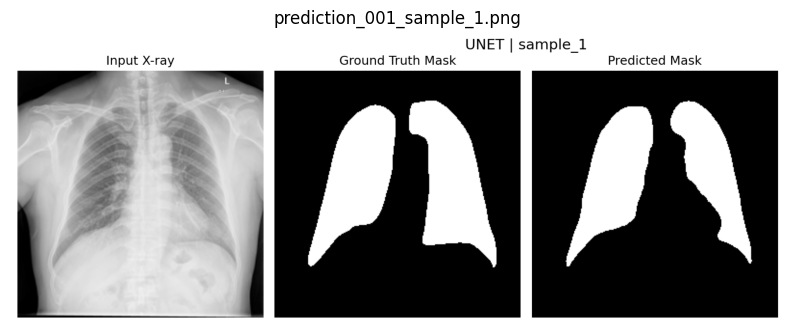

U-Net (SHCXR --> JSRT) : Cross-dataset


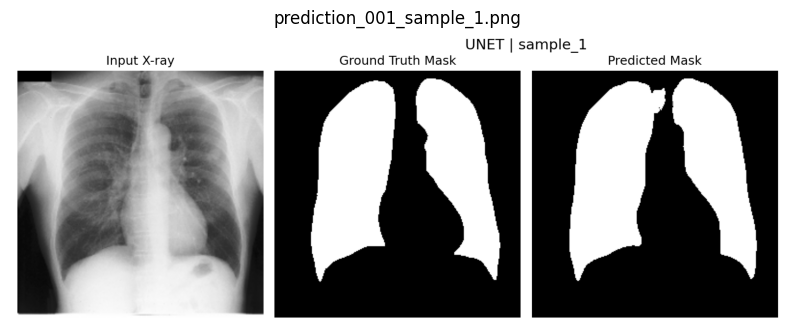

U-Net (JSRT --> JSRT) : Within-dataset


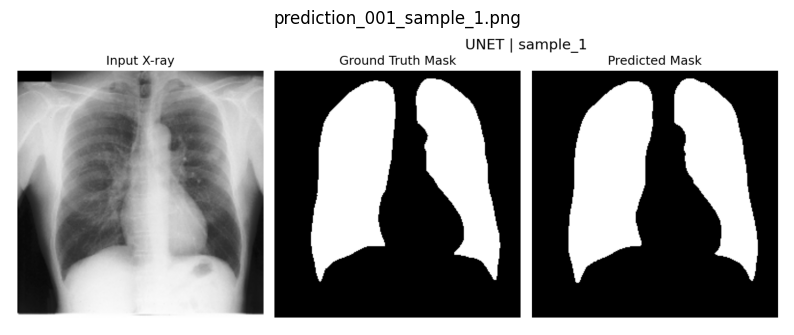

U-Net (JSRT --> SHCXR) : Cross-dataset


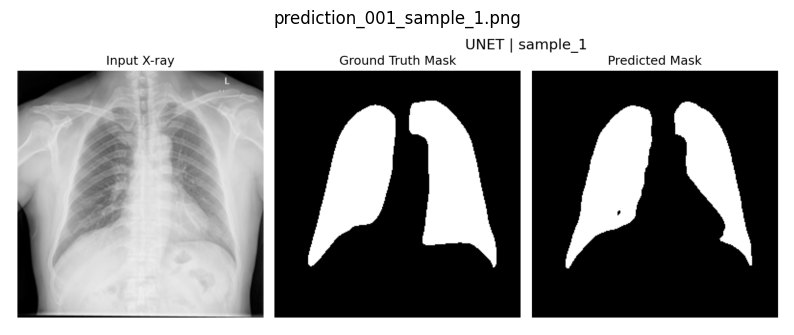


######################################################################

ResUNet (SHCXR --> SHCXR) : Within-dataset


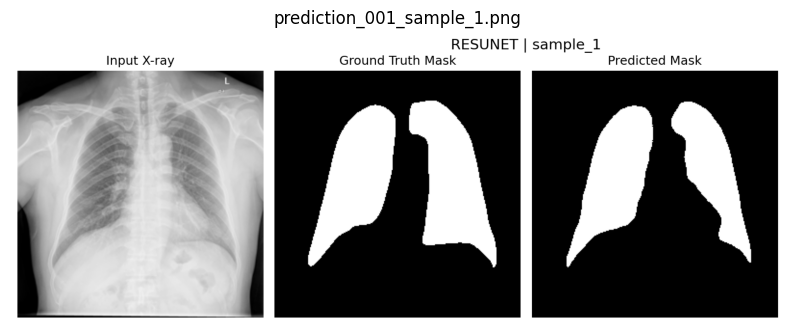

ResUNet (SHCXR --> JSRT) : Cross-dataset


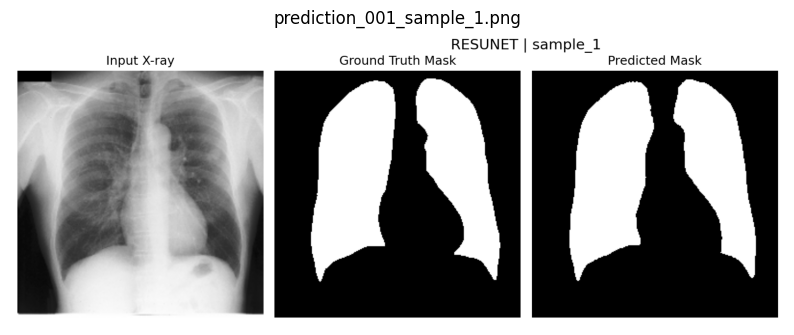

ResUNet (JSRT --> JSRT) : Within-dataset


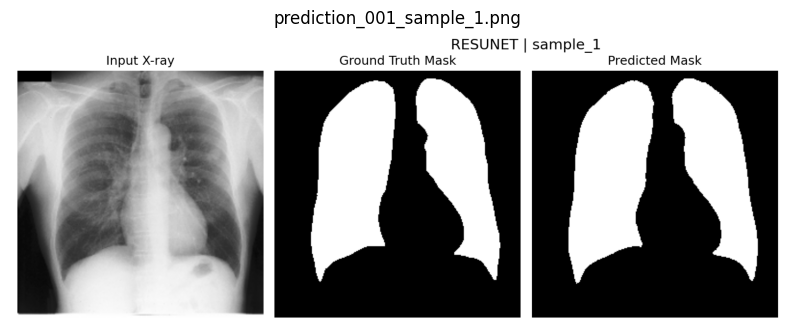

ResUNet (JSRT --> SHCXR) : Cross-dataset


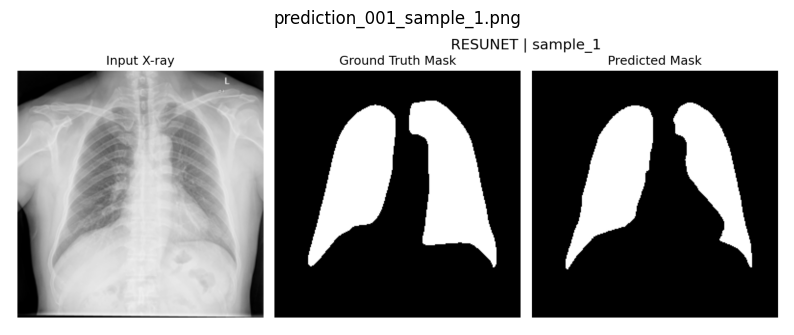

In [20]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

def disp_pred(dir, title, max_img=1):
    folder = Path(dir)
    image_paths = sorted(folder.glob("*.png"))[:max_img]

    if len(image_paths) == 0:
        print(f"No prediction images found in {dir}")
        return

    print(title)

    for img_path in image_paths:
        img = Image.open(img_path)

        plt.figure(figsize=(10, 4))
        plt.imshow(img)
        plt.axis("off")
        plt.title(img_path.name)
        plt.show()



# =========================
# U-NET
# =========================

disp_pred("pred_vis/unet_shcxr_to_shcxr", "U-Net (SHCXR --> SHCXR) : Within-dataset")

print("=" * 60)

disp_pred("pred_vis/unet_shcxr_to_jsrt", "U-Net (SHCXR --> JSRT) : Cross-dataset")

print("=" * 60)

disp_pred("pred_vis/unet_jsrt_to_jsrt", "U-Net (JSRT --> JSRT) : Within-dataset")

print("=" * 60)

disp_pred("pred_vis/unet_jsrt_to_shcxr", "U-Net (JSRT --> SHCXR) : Cross-dataset")


# =========================
# RESUNET
# =========================

print("\n" + "#" * 70 + "\n")

disp_pred("pred_vis/resunet_shcxr_to_shcxr", "ResUNet (SHCXR --> SHCXR) : Within-dataset")

print("=" * 60)

disp_pred("pred_vis/resunet_shcxr_to_jsrt", "ResUNet (SHCXR --> JSRT) : Cross-dataset")

print("=" * 60)

disp_pred("pred_vis/resunet_jsrt_to_jsrt", "ResUNet (JSRT --> JSRT) : Within-dataset")

print("=" * 60)

disp_pred("pred_vis/resunet_jsrt_to_shcxr", "ResUNet (JSRT --> SHCXR) : Cross-dataset")